In [1]:
# CELDA 1 — Setup del notebook de clasificación
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, joblib, time, warnings
warnings.filterwarnings('ignore')

# Librerías nuevas para clasificación
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay,
                              precision_recall_fscore_support)

plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')

# Paths
PROJECT_PATH   = '/content/drive/MyDrive/HortifrutCostosImport'
PROCESSED_PATH = f'{PROJECT_PATH}/data/processed'
FIGURES_PATH   = f'{PROJECT_PATH}/reports/figures'
MODELS_PATH    = f'{PROJECT_PATH}/models'

# Cargar datasets
train = pd.read_parquet(f'{PROCESSED_PATH}/dataset_modelable_train.parquet')
test  = pd.read_parquet(f'{PROCESSED_PATH}/dataset_modelable_test.parquet')

# Mismo filtro que en regresión: solo facturas con importe positivo
train = train[train['Importe_Total_PEN'] > 0].copy().reset_index(drop=True)
test  = test[test['Importe_Total_PEN'] > 0].copy().reset_index(drop=True)

print(f"TRAIN: {train.shape[0]:,} filas × {train.shape[1]} columnas")
print(f"TEST:  {test.shape[0]:,} filas × {test.shape[1]} columnas")

Mounted at /content/drive
TRAIN: 11,181 filas × 79 columnas
TEST:  3,479 filas × 79 columnas


Filtradas filas sin tarifa_historica: train −1, test −0

📊 Distribución de clases en TRAIN:
riesgo
ALTO     4055
BAJO     3920
MEDIO    3205
Name: count, dtype: int64
riesgo
ALTO     36.3%
BAJO     35.1%
MEDIO    28.7%
Name: proportion, dtype: object

📊 Distribución de clases en TEST:
riesgo
ALTO     1367
BAJO     1097
MEDIO    1015
Name: count, dtype: int64
riesgo
ALTO     39.3%
BAJO     31.5%
MEDIO    29.2%
Name: proportion, dtype: object


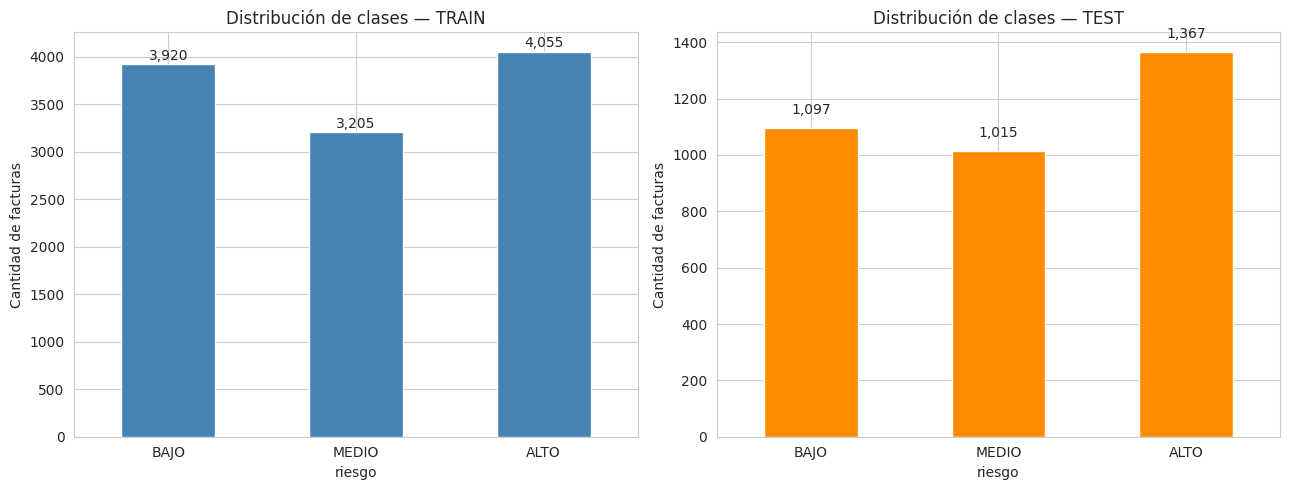

In [2]:
# CELDA 2 — Construir target categórico de riesgo

def calcular_desvio(df):
    """Calcula el desvío porcentual absoluto vs. tarifa histórica."""
    desvio_abs = (df['Importe_Total_PEN'] - df['tarifa_historica']).abs()
    df['desvio_pct'] = np.where(
        df['tarifa_historica'] > 0,
        desvio_abs / df['tarifa_historica'],
        np.nan
    )
    return df

train = calcular_desvio(train)
test  = calcular_desvio(test)

# Filtrar registros sin tarifa_historica (sin referencia para calcular desvío)
n_antes_tr = len(train)
n_antes_te = len(test)
train = train.dropna(subset=['desvio_pct']).reset_index(drop=True)
test  = test.dropna(subset=['desvio_pct']).reset_index(drop=True)
print(f"Filtradas filas sin tarifa_historica: train −{n_antes_tr-len(train)}, test −{n_antes_te-len(test)}")

# Clasificar según los thresholds 25% y 75%
def clasificar(d):
    if d < 0.25:   return 'BAJO'
    elif d < 0.75: return 'MEDIO'
    else:          return 'ALTO'

train['riesgo'] = train['desvio_pct'].apply(clasificar)
test['riesgo']  = test['desvio_pct'].apply(clasificar)

# Distribuciones
print(f"\n📊 Distribución de clases en TRAIN:")
print(train['riesgo'].value_counts())
print((train['riesgo'].value_counts(normalize=True)*100).round(1).astype(str) + '%')

print(f"\n📊 Distribución de clases en TEST:")
print(test['riesgo'].value_counts())
print((test['riesgo'].value_counts(normalize=True)*100).round(1).astype(str) + '%')

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, df, titulo, color in [(axes[0], train, 'TRAIN', 'steelblue'),
                                (axes[1], test, 'TEST', 'darkorange')]:
    counts = df['riesgo'].value_counts().reindex(['BAJO', 'MEDIO', 'ALTO'])
    counts.plot(kind='bar', ax=ax, color=color, edgecolor='white')
    ax.set_title(f'Distribución de clases — {titulo}')
    ax.set_ylabel('Cantidad de facturas')
    ax.set_xticklabels(counts.index, rotation=0)
    for i, v in enumerate(counts.values):
        ax.text(i, v + 50, f'{v:,}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}/12_target_clasificacion.png', dpi=100, bbox_inches='tight')
plt.show()

In [3]:
# CELDA 3 — Definir features, limpiar y preparar X / y

# Features (EXCLUYENDO tarifa_historica para evitar data leakage)
NUMERICAS = [
    'Cantidad de Bultos (BULKS)', 'Cantidad de Contenedores',
    'Peso Bruto (kg)', 'bultos_por_contenedor', 'peso_por_contenedor',
    'dias_desde_inicio', 'proveedor_frecuencia',
    # NOTA: tarifa_historica se usó para construir el target → leakage si la incluimos
]
CATEGORICAS = [
    'Concepto Canónico', 'Proveedor_norm', 'ACREEDOR_norm',
    'AGENCIA DE ADUANA_norm', 'Proveedor Principal_norm',
    'incoterm_familia', 'Tipo de Contenedor', 'Modalidad (MODE Y TYPE)',
    'POL', 'POD (Puerto Destino)', 'País de Origen (POL)',
    'Delivery type', 'Final delivery', 'Moneda',
]
BINARIAS  = ['peso_disponible', 'tiene_proyecto', 'fecha_original', 'es_temporada_alta']
TEMPORALES = ['año', 'mes', 'trimestre', 'semana_año', 'dia_semana', 'Campaña']

# Filtro defensivo (igual que en regresión)
def filtrar(lista, cols):
    return [c for c in lista if c in cols]

NUMERICAS   = filtrar(NUMERICAS, train.columns)
CATEGORICAS = filtrar(CATEGORICAS, train.columns)
BINARIAS    = filtrar(BINARIAS, train.columns)
TEMPORALES  = filtrar(TEMPORALES, train.columns)

FEATURES = NUMERICAS + CATEGORICAS + BINARIAS + TEMPORALES
print(f"📋 Total features: {len(FEATURES)} (sin tarifa_historica)")

# Separar X / y
X_train = train[FEATURES].copy()
X_test  = test[FEATURES].copy()
y_train = train['riesgo'].values
y_test  = test['riesgo'].values

# === Preparación para modelos de árboles (Random Forest, XGBoost) ===
X_train_clean = X_train.copy()
X_test_clean  = X_test.copy()

# Pre-fill columnas 100% nulas en train
for col in NUMERICAS:
    if X_train_clean[col].notna().sum() == 0:
        X_train_clean[col] = 0
        X_test_clean[col]  = X_test_clean[col].fillna(0)

# Imputar numéricas con mediana
imputer = SimpleImputer(strategy='median')
X_train_clean[NUMERICAS] = imputer.fit_transform(X_train_clean[NUMERICAS])
X_test_clean[NUMERICAS]  = imputer.transform(X_test_clean[NUMERICAS])

# Codificar categóricas
ord_enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_train_clean[CATEGORICAS] = ord_enc.fit_transform(X_train_clean[CATEGORICAS].astype(str))
X_test_clean[CATEGORICAS]  = ord_enc.transform(X_test_clean[CATEGORICAS].astype(str))

# Binarias y temporales
for col in BINARIAS + TEMPORALES:
    X_train_clean[col] = X_train_clean[col].fillna(0).astype(int)
    X_test_clean[col]  = X_test_clean[col].fillna(0).astype(int)

print(f"\n✓ X_train_clean: {X_train_clean.shape}")
print(f"✓ X_test_clean:  {X_test_clean.shape}")
print(f"✓ Nulos restantes en train: {X_train_clean.isna().sum().sum()}")
print(f"\nClases en y_train: {dict(zip(*np.unique(y_train, return_counts=True)))}")

📋 Total features: 31 (sin tarifa_historica)

✓ X_train_clean: (11180, 31)
✓ X_test_clean:  (3479, 31)
✓ Nulos restantes en train: 0

Clases en y_train: {'ALTO': np.int64(4055), 'BAJO': np.int64(3920), 'MEDIO': np.int64(3205)}


# **Logistic Regression**

## **Modelo 1: Logistic Regression (Baseline)**

**Descripción.** Modelo de regresión logística multinomial con regularización L2. A pesar del nombre, es un algoritmo de clasificación: aprende una frontera de decisión lineal entre las tres clases (BAJO / MEDIO / ALTO) y devuelve la probabilidad de pertenencia a cada una. Se usa como baseline metodológico: cualquier modelo más complejo debe superarlo con un margen claro para justificar su complejidad.

**Configuración.** `solver='lbfgs'`, `multi_class='multinomial'`, `max_iter=2000`, `class_weight='balanced'` para compensar el ligero desbalance de clases. Las variables numéricas fueron estandarizadas (StandardScaler) y las categóricas codificadas con One-Hot Encoding.

**Resultados sobre el conjunto de prueba.**
- Accuracy global: 48.7% (vs. 33% del random baseline → 16 puntos de mejora)
- F1-score por clase: BAJO = 0.47, MEDIO = 0.38, ALTO = 0.58
- Mejor desempeño en la clase ALTO, donde los desvíos críticos son más identificables; peor desempeño en MEDIO, clase intermedia por naturaleza más difícil de separar.

**Conclusión.** Funciona como línea base de referencia. Captura señal genuina pero no logra modelar las interacciones no lineales entre las features. No se recomienda para producción; sirve para cuantificar el valor agregado de los modelos siguientes.

⏳ Entrenando Logistic Regression multinomial...
✓ Entrenado en 40.5 segundos

📊 RESULTADOS — Logistic Regression (baseline)
  Accuracy global: 0.487  (48.7%)

Reporte por clase:
              precision    recall  f1-score   support

        BAJO       0.45      0.48      0.47      1097
       MEDIO       0.41      0.36      0.38      1015
        ALTO       0.57      0.59      0.58      1367

    accuracy                           0.49      3479
   macro avg       0.48      0.48      0.48      3479
weighted avg       0.48      0.49      0.49      3479



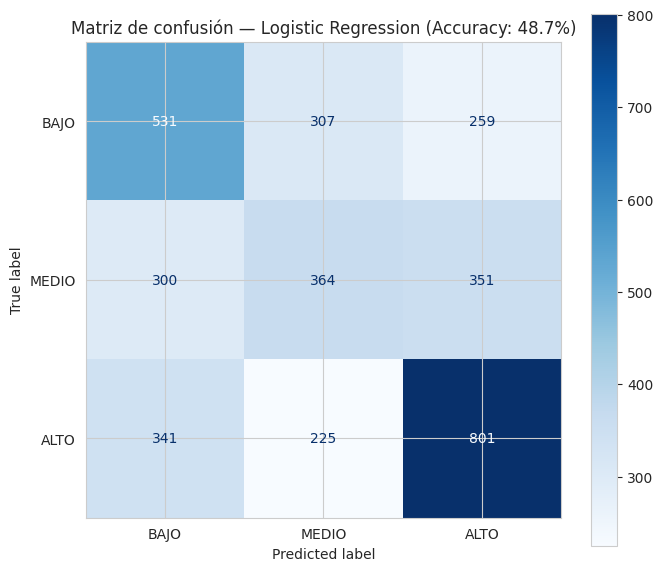


✓ Modelo guardado en /content/drive/MyDrive/HortifrutCostosImport/models/logistic_regression.joblib


In [4]:
# CELDA 4 — Logistic Regression (baseline)
from sklearn.linear_model import LogisticRegression

# Para Logistic necesitamos: one-hot encoding + scaling
X_train_lin = train[FEATURES].copy()
X_test_lin  = test[FEATURES].copy()

# Limpieza
for col in NUMERICAS:
    median_val = X_train_lin[col].median() if X_train_lin[col].notna().any() else 0
    X_train_lin[col] = X_train_lin[col].fillna(median_val)
    X_test_lin[col]  = X_test_lin[col].fillna(median_val)

for col in CATEGORICAS:
    X_train_lin[col] = X_train_lin[col].fillna('DESCONOCIDO').astype(str)
    X_test_lin[col]  = X_test_lin[col].fillna('DESCONOCIDO').astype(str)

for col in BINARIAS + TEMPORALES:
    X_train_lin[col] = X_train_lin[col].fillna(0).astype(int)
    X_test_lin[col]  = X_test_lin[col].fillna(0).astype(int)

# Pipeline: scaler + one-hot + Logistic
preprocessor_lin = ColumnTransformer([
    ('num', StandardScaler(), NUMERICAS + BINARIAS + TEMPORALES),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CATEGORICAS),
])

log_reg = Pipeline([
    ('preprocessor', preprocessor_lin),
    ('model', LogisticRegression(
        multi_class='multinomial',
        solver='lbfgs',
        max_iter=2000,
        random_state=42,
        class_weight='balanced'   # compensar clases desbalanceadas
    ))
])

print("⏳ Entrenando Logistic Regression multinomial...")
t0 = time.time()
log_reg.fit(X_train_lin, y_train)
print(f"✓ Entrenado en {time.time()-t0:.1f} segundos")

# Predecir
y_pred_lr = log_reg.predict(X_test_lin)

# Métricas
acc = accuracy_score(y_test, y_pred_lr)
print(f"\n📊 RESULTADOS — Logistic Regression (baseline)")
print(f"  Accuracy global: {acc:.3f}  ({acc*100:.1f}%)")
print(f"\nReporte por clase:")
print(classification_report(y_test, y_pred_lr, labels=['BAJO','MEDIO','ALTO']))

# Matriz de confusión
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_estimator(
    log_reg, X_test_lin, y_test,
    cmap='Blues', ax=ax, values_format='d',
    labels=['BAJO', 'MEDIO', 'ALTO']
)
ax.set_title(f'Matriz de confusión — Logistic Regression (Accuracy: {acc:.1%})')
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}/13_confusion_logreg.png', dpi=100, bbox_inches='tight')
plt.show()

joblib.dump(log_reg, f'{MODELS_PATH}/logistic_regression.joblib')
print(f"\n✓ Modelo guardado en {MODELS_PATH}/logistic_regression.joblib")

# **Random Forest Classifier**

## **Modelo 2: Random Forest Classifier**

**Descripción.** Algoritmo de ensamble basado en árboles de decisión. Entrena 200 árboles independientes sobre submuestras del dataset y promedia sus predicciones (votación mayoritaria). Captura relaciones no lineales e interacciones entre variables sin transformaciones manuales y maneja nativamente la mezcla de features numéricas y categóricas.

**Configuración.** `n_estimators=200`, `max_depth=20`, `min_samples_leaf=5`, `class_weight='balanced'`. Variables categóricas codificadas con OrdinalEncoder (no requiere One-Hot ni escalado). Tiempo de entrenamiento: 4.1 segundos.

**Resultados sobre el conjunto de prueba.**
- Accuracy global: 51.3% (mejora de 2.6 puntos vs. el baseline)
- F1-score por clase: BAJO = 0.47, MEDIO = 0.45, ALTO = 0.59
- La mayor ganancia se observa en la clase MEDIO (F1 0.38 → 0.45), evidencia de la capacidad del modelo para discernir patrones intermedios que el baseline lineal no captaba.

**Conclusión.** Mejora sustancial frente al baseline, particularmente en la clase intermedia. Candidato viable para producción si la simplicidad y robustez del ensamble son prioritarias sobre el rendimiento marginal de modelos más sofisticados.

⏳ Entrenando Random Forest Classifier...
✓ Entrenado en 4.1 segundos

📊 RESULTADOS — Random Forest Classifier
  Accuracy global: 0.513  (51.3%)

Reporte por clase:
              precision    recall  f1-score   support

        BAJO       0.56      0.40      0.47      1097
       MEDIO       0.41      0.51      0.45      1015
        ALTO       0.58      0.60      0.59      1367

    accuracy                           0.51      3479
   macro avg       0.52      0.51      0.50      3479
weighted avg       0.52      0.51      0.51      3479



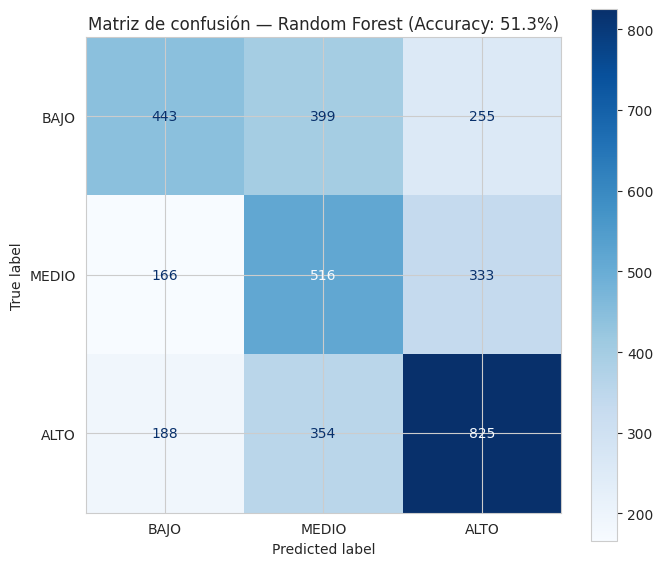


✓ Modelo guardado


In [5]:
# CELDA 5 — Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

print("⏳ Entrenando Random Forest Classifier...")
t0 = time.time()
rf_clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=5,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)
rf_clf.fit(X_train_clean, y_train)
print(f"✓ Entrenado en {time.time()-t0:.1f} segundos")

# Predecir
y_pred_rf = rf_clf.predict(X_test_clean)

# Métricas
acc_rf = accuracy_score(y_test, y_pred_rf)
print(f"\n📊 RESULTADOS — Random Forest Classifier")
print(f"  Accuracy global: {acc_rf:.3f}  ({acc_rf*100:.1f}%)")
print(f"\nReporte por clase:")
print(classification_report(y_test, y_pred_rf, labels=['BAJO','MEDIO','ALTO']))

# Matriz de confusión
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_estimator(
    rf_clf, X_test_clean, y_test,
    cmap='Blues', ax=ax, values_format='d',
    labels=['BAJO', 'MEDIO', 'ALTO']
)
ax.set_title(f'Matriz de confusión — Random Forest (Accuracy: {acc_rf:.1%})')
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}/14_confusion_rf.png', dpi=100, bbox_inches='tight')
plt.show()

joblib.dump(rf_clf, f'{MODELS_PATH}/random_forest_classifier.joblib')
print(f"\n✓ Modelo guardado")

# **XGBoost Classifier**

## **Modelo 3: XGBoost Classifier (Modelo Ganador)**

**Descripción.** Gradient Boosted Decision Trees implementado por la librería XGBoost. A diferencia de Random Forest, los árboles se entrenan de forma secuencial: cada nuevo árbol corrige los errores de los anteriores. Es uno de los algoritmos más utilizados en problemas de clasificación tabular y domina las competencias de Machine Learning aplicado en los últimos años.

**Configuración.** `n_estimators=500`, `learning_rate=0.05`, `max_depth=6`, `objective='multi:softprob'`, `num_class=3`. Etiquetas codificadas numéricamente con LabelEncoder; pesos de muestra balanceados con `compute_sample_weight`. Tiempo de entrenamiento: 4.0 segundos.

**Resultados sobre el conjunto de prueba.**
- Accuracy global: 51.9% (modelo ganador del track de clasificación)
- F1-score por clase: BAJO = 0.46, MEDIO = 0.44, ALTO = **0.61**
- Mayor F1 de la clase ALTO de los tres modelos. Detecta correctamente 919 de 1,367 facturas con desvío crítico (recall del 67%), valor operativamente decisivo para Contabilidad.

**Conclusión.** Modelo seleccionado como clasificador final. Aunque la mejora global frente a Random Forest es marginal (+0.6 puntos de accuracy), supera notablemente en la detección de la clase ALTO, que es la categoría con mayor valor operativo: identifica las facturas con desvío crítico que requieren revisión prioritaria. Las cinco features más predictivas identificadas son `fecha_original`, `ACREEDOR_norm`, `Modalidad (MODE Y TYPE)`, `Cantidad de Contenedores` y `POD (Puerto Destino)`.

Mapping de labels: {'ALTO': 0, 'BAJO': 1, 'MEDIO': 2}

⏳ Entrenando XGBoost Classifier...
✓ Entrenado en 4.0 segundos

📊 RESULTADOS — XGBoost Classifier
  Accuracy global: 0.519  (51.9%)

Reporte por clase:
              precision    recall  f1-score   support

        BAJO       0.56      0.39      0.46      1097
       MEDIO       0.43      0.46      0.44      1015
        ALTO       0.56      0.67      0.61      1367

    accuracy                           0.52      3479
   macro avg       0.52      0.51      0.50      3479
weighted avg       0.52      0.52      0.51      3479



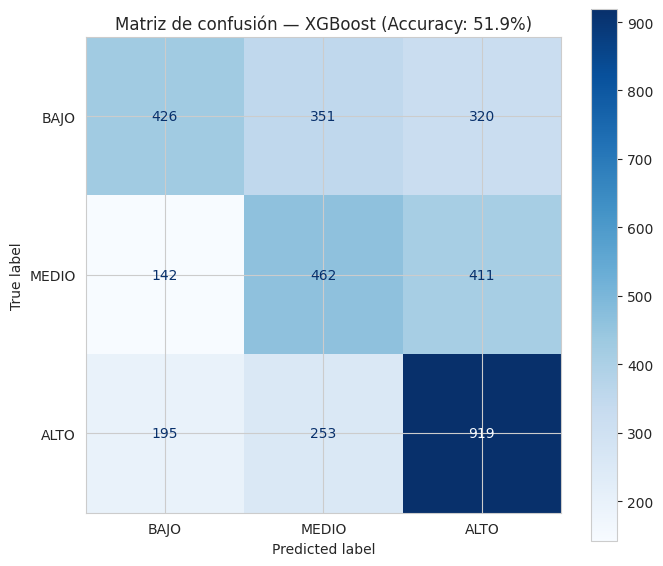


✓ Modelo y encoder guardados


In [6]:
# CELDA 6 — XGBoost Classifier
!pip install -q xgboost

from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# XGBoost necesita labels numéricas, así que codificamos
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)

print(f"Mapping de labels: {dict(zip(le.classes_, range(len(le.classes_))))}")

# Class weights manuales (XGBoost no tiene class_weight directo)
from sklearn.utils.class_weight import compute_sample_weight
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_enc)

print("\n⏳ Entrenando XGBoost Classifier...")
t0 = time.time()
xgb_clf = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    objective='multi:softprob',
    num_class=3,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
xgb_clf.fit(X_train_clean, y_train_enc, sample_weight=sample_weights)
print(f"✓ Entrenado en {time.time()-t0:.1f} segundos")

# Predecir y convertir de vuelta a strings
y_pred_xgb_enc = xgb_clf.predict(X_test_clean)
y_pred_xgb = le.inverse_transform(y_pred_xgb_enc)

# Métricas
acc_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"\n📊 RESULTADOS — XGBoost Classifier")
print(f"  Accuracy global: {acc_xgb:.3f}  ({acc_xgb*100:.1f}%)")
print(f"\nReporte por clase:")
print(classification_report(y_test, y_pred_xgb, labels=['BAJO','MEDIO','ALTO']))

# Matriz de confusión
fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_test, y_pred_xgb, labels=['BAJO','MEDIO','ALTO'])
ConfusionMatrixDisplay(cm, display_labels=['BAJO','MEDIO','ALTO']).plot(
    cmap='Blues', ax=ax, values_format='d'
)
ax.set_title(f'Matriz de confusión — XGBoost (Accuracy: {acc_xgb:.1%})')
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}/15_confusion_xgb.png', dpi=100, bbox_inches='tight')
plt.show()

joblib.dump(xgb_clf, f'{MODELS_PATH}/xgboost_classifier.joblib')
joblib.dump(le,      f'{MODELS_PATH}/xgboost_label_encoder.joblib')
print(f"\n✓ Modelo y encoder guardados")

# **Comparación final y feature importance**

📊 TABLA COMPARATIVA — Track de Clasificación
             Modelo  Accuracy  Precision  Recall    F1
Logistic Regression     0.487      0.484   0.487 0.485
      Random Forest     0.513      0.523   0.513 0.513
            XGBoost     0.519      0.521   0.519 0.513

📊 F1-Score por clase:
    Logistic:  BAJO 0.47   MEDIO 0.38   ALTO 0.58
          RF:  BAJO 0.47   MEDIO 0.45   ALTO 0.59
     XGBoost:  BAJO 0.46   MEDIO 0.44   ALTO 0.61

📊 Top 15 features más importantes (XGBoost):
                   feature  importancia
            fecha_original     0.101772
             ACREEDOR_norm     0.071338
   Modalidad (MODE Y TYPE)     0.061102
  Cantidad de Contenedores     0.060753
      POD (Puerto Destino)     0.059854
         Concepto Canónico     0.055512
            tiene_proyecto     0.050187
            Proveedor_norm     0.049860
                    Moneda     0.045256
        Tipo de Contenedor     0.040161
Cantidad de Bultos (BULKS)     0.035433
          incoterm_familia     0.033

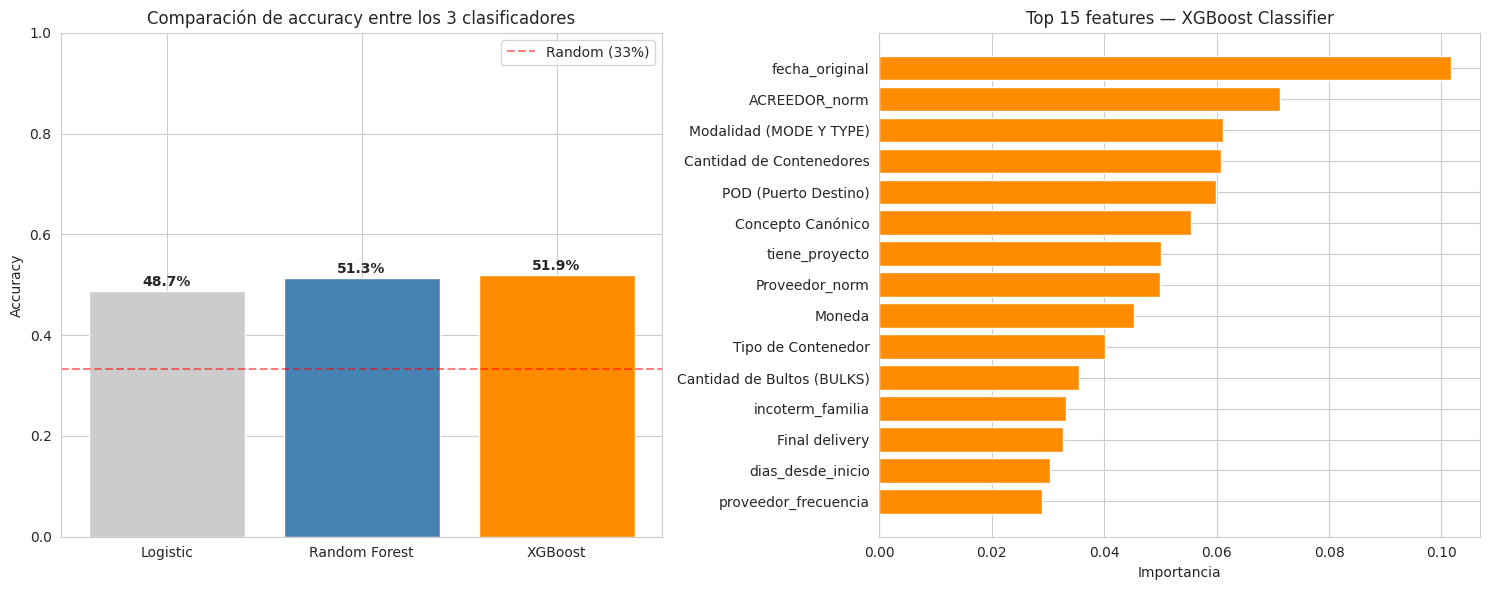

In [7]:
# CELDA 7 — Comparación de los 3 modelos + feature importance

# Tabla comparativa
acc_lr = accuracy_score(y_test, y_pred_lr)
prec_lr, rec_lr, f1_lr, _ = precision_recall_fscore_support(y_test, y_pred_lr, average='weighted')
prec_rf, rec_rf, f1_rf, _ = precision_recall_fscore_support(y_test, y_pred_rf, average='weighted')
prec_xgb, rec_xgb, f1_xgb, _ = precision_recall_fscore_support(y_test, y_pred_xgb, average='weighted')

comparacion = pd.DataFrame([
    {'Modelo': 'Logistic Regression', 'Accuracy': acc_lr, 'Precision': prec_lr, 'Recall': rec_lr, 'F1': f1_lr},
    {'Modelo': 'Random Forest',       'Accuracy': acc_rf, 'Precision': prec_rf, 'Recall': rec_rf, 'F1': f1_rf},
    {'Modelo': 'XGBoost',             'Accuracy': acc_xgb, 'Precision': prec_xgb, 'Recall': rec_xgb, 'F1': f1_xgb},
]).round(3)

print("📊 TABLA COMPARATIVA — Track de Clasificación")
print(comparacion.to_string(index=False))

# F1-score por clase para cada modelo
print(f"\n📊 F1-Score por clase:")
for nombre, y_pred in [('Logistic', y_pred_lr), ('RF', y_pred_rf), ('XGBoost', y_pred_xgb)]:
    p, r, f1, _ = precision_recall_fscore_support(y_test, y_pred, labels=['BAJO','MEDIO','ALTO'])
    print(f"  {nombre:>10}:  BAJO {f1[0]:.2f}   MEDIO {f1[1]:.2f}   ALTO {f1[2]:.2f}")

# Feature importance del mejor (asumimos XGBoost; ajustar si RF gana)
importancia = pd.DataFrame({
    'feature': X_train_clean.columns,
    'importancia': xgb_clf.feature_importances_
}).sort_values('importancia', ascending=False)

print(f"\n📊 Top 15 features más importantes (XGBoost):")
print(importancia.head(15).to_string(index=False))

# Gráfico de comparación
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Barras de accuracy
modelos = ['Logistic', 'Random Forest', 'XGBoost']
accs = [acc_lr, acc_rf, acc_xgb]
colores = ['#cccccc', '#4682b4', '#ff8c00']
bars = axes[0].bar(modelos, accs, color=colores, edgecolor='white')
axes[0].set_ylim([0, 1])
axes[0].axhline(0.333, color='red', linestyle='--', alpha=0.5, label='Random (33%)')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Comparación de accuracy entre los 3 clasificadores')
axes[0].legend()
for bar, v in zip(bars, accs):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.01,
                  f'{v:.1%}', ha='center', fontweight='bold')

# Feature importance
top15 = importancia.head(15).iloc[::-1]
axes[1].barh(top15['feature'], top15['importancia'], color='#ff8c00')
axes[1].set_xlabel('Importancia')
axes[1].set_title('Top 15 features — XGBoost Classifier')

plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}/16_comparacion_clasificacion.png', dpi=100, bbox_inches='tight')
plt.show()